# TC50 O2 vs Concentration Plots

This notebook creates 2D plots of O2 percentage vs drug concentration at specific time points.

**Purpose:** Visualize dose-response relationships at critical time points to identify TC50 (concentration at 50% O2 response).

**Data Source:** `Cleaned_Data/DrugScreen19.11.25_compiled_O2_mean.xlsx`

**Target Drugs & Time Points:**
- Sunitinib: 32, 35 hrs
- Daunorubicin: 27, 30, 32 hrs
- Erlotinib: 22, 24, 27 hrs
- Vandetanib: 14, 27, 40 hrs
- Epirubicin: 24, 30 hrs

**Output:** One figure per drug with subplots for each time point showing O2 vs concentration.

In [1]:
# Cell #1
# Purpose: Setup and Imports

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple, Optional

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['legend.fontsize'] = 10

print("✓ Imports loaded successfully")

✓ Imports loaded successfully


In [2]:
# Cell #2
# Depends on: 1
# Purpose: Path Configuration

current_dir = Path.cwd()

if current_dir.name == 'Prediction_Models':
    PROJECT_ROOT = current_dir.parent
elif (current_dir / 'EQN_Coefficients').exists():
    PROJECT_ROOT = current_dir
elif (current_dir.parent / 'EQN_Coefficients').exists():
    PROJECT_ROOT = current_dir.parent
else:
    PROJECT_ROOT = current_dir

# Define paths
DATA_PATH = PROJECT_ROOT / 'Cleaned_Data' / 'DrugScreen19.11.25_compiled_O2_mean.xlsx'
OUTPUT_DIR = PROJECT_ROOT / 'Output' / 'TC50_Plots'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"✓ Project root: {PROJECT_ROOT}")
print(f"✓ Data file: {DATA_PATH}")
print(f"  {'[FOUND]' if DATA_PATH.exists() else '[NOT FOUND - CHECK PATH]'}")
print(f"✓ Output directory: {OUTPUT_DIR}")

✓ Project root: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO
✓ Data file: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Cleaned_Data\DrugScreen19.11.25_compiled_O2_mean.xlsx
  [FOUND]
✓ Output directory: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Output\TC50_Plots


In [3]:
# Cell #4
# Depends on: 1, 2
# Purpose: Load O2 data from multi-sheet Excel file

print("Loading O2 data from multiple sheets...\n")

xl_file = pd.ExcelFile(DATA_PATH)
print("📋 Available sheets in Excel file:")
for sheet in xl_file.sheet_names:
    print(f"  - {sheet}")

print("\n" + "="*80 + "\n")

drug_data = {}

def parse_first_row_time_first_col_conc(df_sheet):
    """
    Expected layout per sheet:
    - Row 0 (col 1+): time points (hours)
    - Col 0 (row 1+): concentrations (mM)
    - Data block: rows 1+, cols 1+ = O2 values
    """
    time_row = df_sheet.iloc[0, 1:].dropna()
    time_points = time_row.astype(float).to_numpy()

    conc_col = df_sheet.iloc[1:, 0].dropna()
    concentrations = conc_col.astype(float).to_numpy()

    rows = len(concentrations)
    cols = len(time_points)
    o2_block = df_sheet.iloc[1:1+rows, 1:1+cols].to_numpy(dtype=float)

    return time_points, concentrations, o2_block

for sheet_name in xl_file.sheet_names:
    df_sheet = pd.read_excel(DATA_PATH, sheet_name=sheet_name, header=None)
    
    if 'O2_mean' in sheet_name or 'O2' in sheet_name:
        # Extract drug name from sheet name
        drug_name = sheet_name.replace(' O2_mean', '').replace('O2_mean', '').replace(' O2', '').replace('O2', '').strip()
        
        # If drug name is empty, try getting from first cell
        if pd.isna(drug_name) or drug_name == '':
            cell_val = df_sheet.iloc[0, 0]
            if pd.notna(cell_val):
                drug_name = str(cell_val).strip()
        
        print(f"📊 {drug_name}:")
        print(f"   Sheet: {sheet_name}")
        print(f"   Shape: {df_sheet.shape}")
        
        time_points, concentrations, o2_matrix = parse_first_row_time_first_col_conc(df_sheet)

        if len(time_points) == 0 or len(concentrations) == 0:
            print("   ⚠ No time points or concentrations detected; skipping sheet")
            continue
        
        print(f"   Time points ({len(time_points)}): {time_points[:8].tolist()}{'...' if len(time_points) > 8 else ''}")
        print(f"   Concentrations ({len(concentrations)}): {concentrations[:8].tolist()}{'...' if len(concentrations) > 8 else ''}")
        print(f"   O2 matrix shape: {o2_matrix.shape} (rows=concentrations, cols=time points)")
        
        drug_data[drug_name] = {
            'sheet_name': sheet_name,
            'time_points': time_points,
            'concentrations': concentrations,
            'o2_matrix': o2_matrix,
            'df_raw': df_sheet
        }
        print(f"   ✓ Loaded successfully\n")

print("="*80)
print(f"\n✓ Loaded {len(drug_data)} drug sheets")
print(f"✓ Drugs found: {list(drug_data.keys())}")

# Store for later use - this is a dictionary!
df_o2_raw = drug_data


Loading O2 data from multiple sheets...

📋 Available sheets in Excel file:
  - All_Drugs
  - Amiodarone O2_mean
  - Bortezomib O2_mean
  - Chlorpromazine O2_mean
  - Cobimetinib O2_mean
  - Dactinomycin O2_mean
  - Daunorubicin of O2_mean
  - Doxorubicin O2_mean
  - Epirubicin O2_mean
  - Erlotinib O2_mean
  - Etomoxir O2_mean
  - Gemcitibine O2_mean
  - Ibrutinib O2_mean
  - Ibuprofen O2_mean
  - Isoproterenol O2_mean
  - Mexiletine O2_mean
  - Nifedipine O2_mean
  - Panobinostat O2_mean
  - Plicamycin O2_mean
  - Rosiglitazone O2_mean
  - Sotalol O2_mean
  - Sunitinib O2_mean
  - Vandetanib O2_mean
  - Vincristine O2_mean
  - Vioxx O2_mean
  - Vorinostat O2_mean


📊 Amiodarone:
   Sheet: Amiodarone O2_mean
   Shape: (26, 33)
   Time points (32): [3.0, 7.0, 18.0, 21.0, 24.0, 26.0, 29.0, 31.0]...
   Concentrations (25): [10.0, 10.0, 5.0, 5.0, 5.0, 2.5, 2.5, 2.5]...
   O2 matrix shape: (25, 32) (rows=concentrations, cols=time points)
   ✓ Loaded successfully

📊 Bortezomib:
   Sheet: Bor

## Data Structure Analysis

**After running the cell above, examine the data structure:**
- Each drug is loaded from its corresponding sheet (e.g., "Sunitinib O2_mean")
- `drug_data[drug_name]` contains: time_points, concentrations, o2_matrix
- `o2_matrix[i, j]` = O2 value at concentration[i] and time_points[j]

In [4]:
# Cell #5
# Depends on: 1, 4
# Purpose: Helper Functions

from scipy.optimize import curve_fit
from datetime import datetime
import warnings

def get_drug_data(drug_name: str, drug_data_dict: dict) -> Optional[dict]:
    """
    Get data dictionary for a specific drug (case-insensitive, partial match fallback).
    Data layout: time_points along columns, concentrations along rows (o2_matrix[row, col]).
    """
    # Exact match first
    if drug_name in drug_data_dict:
        return drug_data_dict[drug_name]

    # Case-insensitive match
    for key in drug_data_dict.keys():
        if key.lower() == drug_name.lower():
            return drug_data_dict[key]

    # Partial match (drug name contains or is contained in key)
    for key in drug_data_dict.keys():
        if drug_name.lower() in key.lower() or key.lower() in drug_name.lower():
            print(f"   ⚠ Using partial match: '{key}' for '{drug_name}'")
            return drug_data_dict[key]

    return None


def align_o2_matrix(drug_dict: dict) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Ensure matrix dims match concentrations (rows) and time_points (cols).
    Returns trimmed/aligned (concentrations, time_points, o2_matrix).
    """
    time_points = np.asarray(drug_dict['time_points'], dtype=float)
    concentrations = np.asarray(drug_dict['concentrations'], dtype=float)
    o2_matrix = np.asarray(drug_dict['o2_matrix'], dtype=float)

    rows = min(len(concentrations), o2_matrix.shape[0])
    cols = min(len(time_points), o2_matrix.shape[1])

    if (rows, cols) != o2_matrix.shape:
        o2_matrix = o2_matrix[:rows, :cols]
        time_points = time_points[:cols]
        concentrations = concentrations[:rows]
        print(f"   ℹ Adjusted matrix to {o2_matrix.shape} to align with rows/cols")

    return concentrations, time_points, o2_matrix


def get_o2_at_timepoint(drug_dict: dict, target_time: float, tolerance: float = 1.0) -> Tuple[np.ndarray, np.ndarray]:
    """
    Extract concentration and O2 response arrays for a specific time point.
    """
    concentrations, time_points, o2_matrix = align_o2_matrix(drug_dict)

    # Find closest time point
    time_diffs = np.abs(time_points - target_time)
    closest_idx = np.argmin(time_diffs)

    if time_diffs[closest_idx] > tolerance:
        print(f"   ⚠ No time point within {tolerance}h of {target_time}h")
        print(f"      Closest: {time_points[closest_idx]}h (diff: {time_diffs[closest_idx]:.1f}h)")
        return np.array([]), np.array([])

    actual_time = time_points[closest_idx]
    if actual_time != target_time:
        print(f"   ℹ Using {actual_time}h (closest to {target_time}h)")

    # Extract O2 values at this time point
    o2_values = o2_matrix[:, closest_idx]

    return concentrations, o2_values


def sanitize_filename(name: str) -> str:
    """Remove invalid filename characters."""
    return name.replace('/', '_').replace('\\', '_').replace(' ', '_').replace(':', '_')


def logistic_curve(xlog, bottom, top, logEC50, slope):
    """4-parameter logistic curve for dose-response modeling."""
    return bottom + (top - bottom) / (1 + np.exp((logEC50 - xlog) * slope))


def plot_single_timepoint(ax, drug_info, tp, color, drug_name):
    """
    Plot a single drug/timepoint on the given axis.
    Returns: (tc50_fit, df_export) tuple
    """
    conc, o2_vals = get_o2_at_timepoint(drug_info, tp)

    if len(conc) == 0:
        ax.text(0.5, 0.5, f"No data at {tp}h", ha='center', va='center', transform=ax.transAxes)
        ax.axis('off')
        return None, None

    # Process data
    df_tp = pd.DataFrame({'Concentration': conc, 'O2': o2_vals})
    df_avg = df_tp.groupby('Concentration', as_index=False).mean().sort_values('Concentration')
    df_avg['Consumption'] = 80.0 - df_avg['O2']
    df_plot_log = df_avg[df_avg['Concentration'] > 0].copy()

    if df_plot_log.empty:
        ax.text(0.5, 0.5, "Non-positive concentrations only", ha='center', va='center', transform=ax.transAxes)
        ax.axis('off')
        return None, None

    x_conc = df_plot_log['Concentration'].to_numpy()
    y_cons = df_plot_log['Consumption'].to_numpy()
    x_log = np.log10(x_conc)

    # Scatter points
    ax.plot(x_conc, y_cons, 'o', markersize=7, color=color, label='Mean consumption')

    # Sigmoid fit
    tc50_fit = None
    try:
        if len(x_log) >= 3:
            p0 = [y_cons.min(), y_cons.max(), np.median(x_log), 1.0]
            popt, _ = curve_fit(logistic_curve, x_log, y_cons, p0=p0, maxfev=20000)
            x_smooth = np.linspace(x_log.min() - 0.2, x_log.max() + 0.2, 200)
            conc_smooth = 10 ** x_smooth
            y_smooth = logistic_curve(x_smooth, *popt)
            ax.plot(conc_smooth, y_smooth, '-', color=color, linewidth=2, label='Sigmoid fit')

            bottom, top, logEC50, slope = popt
            denom = top - bottom
            target = 50.0
            if slope != 0 and denom != 0:
                denom_target = target - bottom
                if denom_target != 0:
                    ratio = denom / denom_target - 1.0
                    if ratio > 0:
                        tc50_log = logEC50 - (1.0 / slope) * np.log(ratio)
                        tc50_fit = 10 ** tc50_log
    except Exception as err:
        print(f"   ⚠ Sigmoid fit failed at {tp}h: {err}")

    # Add TC50 markers
    if tc50_fit is not None and np.isfinite(tc50_fit):
        ax.axhline(y=50, color='gray', linestyle='--', linewidth=1.2, alpha=0.7)
        ax.axvline(x=tc50_fit, color='red', linestyle='--', linewidth=1.2, alpha=0.7)
        ax.text(0.05, 0.1, f"TC50={tc50_fit:.3f} mM", transform=ax.transAxes,
                fontsize=10, fontweight='bold')
    else:
        ax.text(0.05, 0.1, "TC50 = N/A", transform=ax.transAxes,
                fontsize=10, fontweight='bold')

    # Style the axis
    ax.set_xscale('log')
    ax.set_xticks(x_conc)
    ax.set_xticklabels([f"{x:.3g}" for x in x_conc])
    ax.set_xlabel('Concentration (mM)', fontsize=12, fontweight='bold')
    ax.set_ylabel('O2 Consumption (%)', fontsize=12, fontweight='bold')
    ax.set_title(f"{tp} h", fontsize=13, fontweight='bold')
    ax.set_ylim(0, 100)
    ax.set_xlim(x_conc.min() * 0.9, x_conc.max() * 1.1)
    ax.grid(True, alpha=0.3, which='both')
    ax.legend(loc='best', fontsize=9)

    # Prepare export data
    df_export = df_avg.copy()
    df_export.rename(columns={'Consumption': 'O2_Consumption', 'O2': 'O2_Percentage',
                              'Concentration': 'Concentration_mM'}, inplace=True)
    df_export['Timepoint_hours'] = tp
    df_export['TC50_mM'] = tc50_fit if tc50_fit is not None else np.nan

    return tc50_fit, df_export


def generate_tc50_plots(drug_selections, drug_data, output_dir, save_files=False, test_mode=False):
    """
    Generate TC50 plots for multiple drugs and timepoints.

    Args:
        drug_selections: dict mapping drug names to list of timepoints
        drug_data: dict containing drug measurement data
        output_dir: Path to save output files
        save_files: bool, whether to save PNG and Excel files
        test_mode: bool, whether this is a test run (affects titles)

    Returns:
        tuple: (tc50_results, drug_export_data)
    """
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    tc50_results = []
    drug_export_data = {}

    mode_label = " (TEST)" if test_mode else ""

    for drug_name, timepoints in drug_selections.items():
        print(f"\n🔬 {drug_name}")
        print(f"   Time points: {timepoints}")

        drug_info = get_drug_data(drug_name, drug_data)

        if drug_info is None:
            print("   ⚠ No data found (skipping)")
            print(f"   Available: {list(drug_data.keys())[:5]}...")
            continue

        # Create figure
        fig, axes = plt.subplots(1, len(timepoints), figsize=(6 * len(timepoints), 5), squeeze=False)
        fig.suptitle(f"{drug_name} – Concentration vs O2 Consumption{mode_label}",
                     fontsize=16, fontweight='bold')

        # Assign color
        colors = plt.cm.tab10.colors
        drug_list = list(drug_selections.keys())
        color_idx = drug_list.index(drug_name) if drug_name in drug_list else 0
        color = colors[color_idx % len(colors)]

        # Store data for this drug
        drug_sheets = []

        # Plot each timepoint
        for ax, tp in zip(axes.flat, timepoints):
            tc50_fit, df_export = plot_single_timepoint(ax, drug_info, tp, color, drug_name)

            if tc50_fit is not None and np.isfinite(tc50_fit):
                tc50_results.append({'Drug': drug_name, 'Time_h': tp, 'TC50_mM': tc50_fit})

            if df_export is not None:
                df_export['Timestamp'] = timestamp
                df_export = df_export[['Timepoint_hours', 'Concentration_mM', 'O2_Percentage',
                                       'O2_Consumption', 'TC50_mM', 'Timestamp']]
                drug_sheets.append((tp, df_export))

        plt.tight_layout(rect=[0, 0, 1, 0.95])

        # Save plot if requested
        if save_files:
            save_path = output_dir / f"{sanitize_filename(drug_name)}_TC50.png"
            plt.savefig(save_path, dpi=300, bbox_inches='tight', transparent=True)
            print(f"   💾 Saved panel figure: {save_path.name}")
        else:
            print(f"   ✓ Preview displayed (not saved)")

        plt.show()

        if drug_sheets:
            drug_export_data[drug_name] = drug_sheets

    return tc50_results, drug_export_data, timestamp


def save_tc50_excel(drug_export_data, tc50_results, timestamp, output_dir):
    """Save TC50 data to Excel file with summary and individual sheets."""
    if not drug_export_data:
        print("\n⚠ No data to save")
        return None

    excel_path = output_dir / f"TC50_{datetime.now().strftime('%Y%m%d_%H%M%S')}.xlsx"

    print("\n" + "=" * 80)
    print(f"💾 Saving Data to Excel: {excel_path.name}")
    print("=" * 80)

    with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
        # Summary sheet
        summary_rows = []
        for drug_name, sheets_list in drug_export_data.items():
            for tp, df_tp in sheets_list:
                tc50 = df_tp['TC50_mM'].iloc[0] if not df_tp['TC50_mM'].isna().all() else None
                summary_rows.append({
                    'Drug': drug_name,
                    'Timepoint_hours': tp,
                    'TC50_mM': tc50,
                    'Num_Concentrations': len(df_tp),
                    'Timestamp': timestamp
                })

        df_summary = pd.DataFrame(summary_rows)
        df_summary.to_excel(writer, sheet_name='Summary', index=False)
        print(f"\n   ✓ Summary sheet: {len(df_summary)} entries")

        # Individual sheets
        for drug_name, sheets_list in drug_export_data.items():
            for tp, df_tp in sheets_list:
                sheet_name = f"{drug_name}_{int(tp)}h"
                if len(sheet_name) > 31:
                    sheet_name = sheet_name[:31]

                df_tp.to_excel(writer, sheet_name=sheet_name, index=False)
                print(f"   ✓ {sheet_name}: {len(df_tp)} rows")

    print("\n" + "=" * 80)
    print(f"✅ Excel file saved successfully!")
    print(f"   Location: {excel_path}")
    print(f"   Total sheets: {1 + sum(len(sheets) for sheets in drug_export_data.values())}")
    print(f"   Timestamp: {timestamp}")
    print("=" * 80)

    # Display TC50 summary
    if tc50_results:
        df_tc50 = pd.DataFrame(tc50_results)
        print("\n📊 TC50 SUMMARY:")
        display(df_tc50)

    return excel_path


print("✓ Helper and plotting functions defined")


✓ Helper and plotting functions defined


## Notes & Customization

### Data Structure

The Excel file contains multiple sheets, one per drug (e.g., "Sunitinib O2_mean").

Each sheet structure:
- Row 0: Drug name header
- Row 1: 'Scale' label, then time points starting at column 2
- Row 2+: Well info (col 0), concentrations (col 1), O2 values (cols 2+)

### TC50 Calculation

The `calculate_tc50()` function assumes:
- Baseline (100%) is the maximum O2 value (typically at lowest concentration)
- TC50 is where O2 drops to 50% of baseline
- Linear interpolation between measured points

### Troubleshooting

If plots show "No data" messages:
1. Check drug names match exactly (case-insensitive matching is supported)
2. Verify time points exist in the data (tolerance is ±1h)
3. Check the output of Cell 4 to see available drugs and time points

## Custom Plot Testing (No Saving)

Use this section to test and preview plots for specific drugs and time points without saving any files.

**Purpose:** Quickly iterate on drug/timepoint selections to find visually interesting results before committing to save.

🧪 Testing Custom Plot Selection (NOT saving)...

🔬 Epirubicin
   Time points: [24, 27, 32, 38, 17]
   ✓ Preview displayed (not saved)


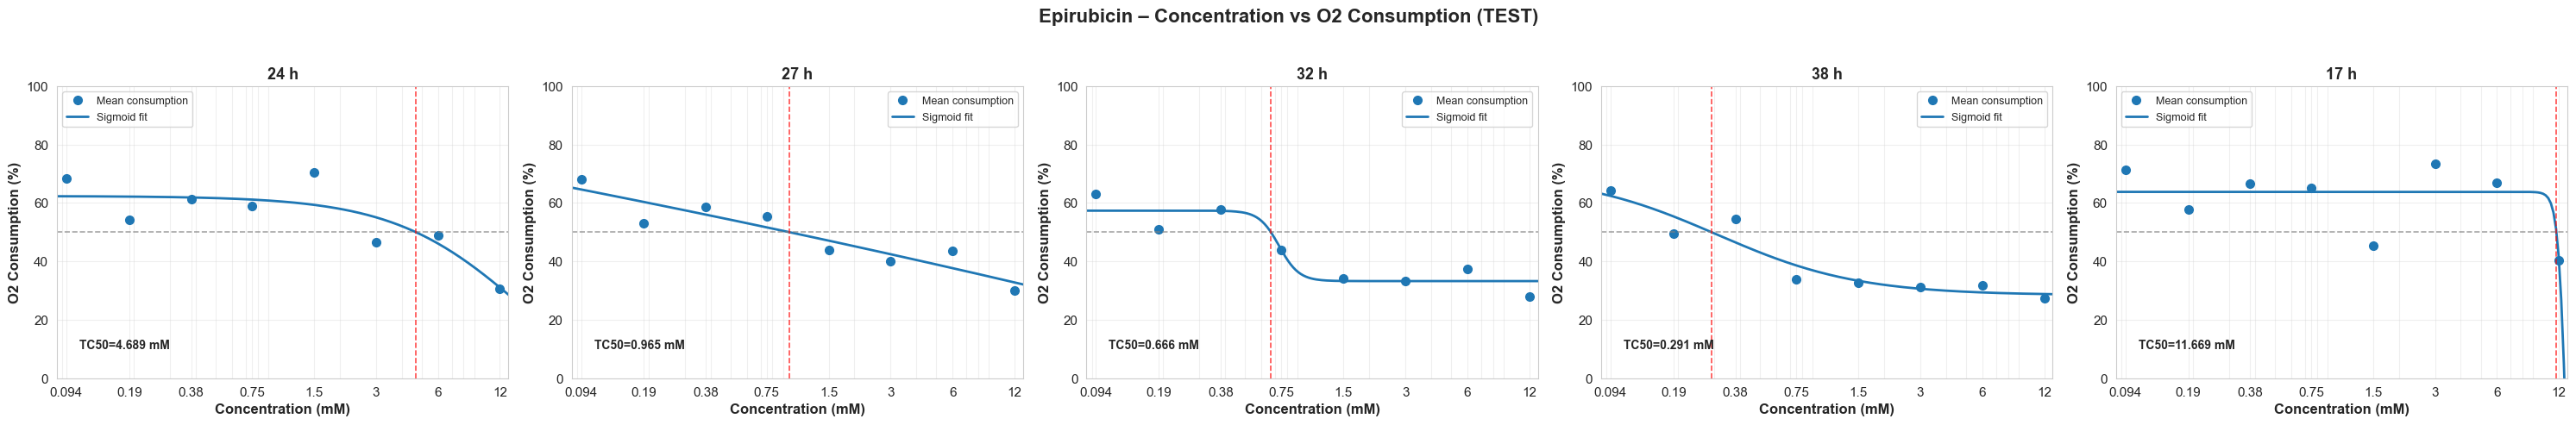


🔬 Daunorubicin
   Time points: [32, 38, 56, 59, 61]
   ⚠ Using partial match: 'Daunorubicin of' for 'Daunorubicin'
   ✓ Preview displayed (not saved)


C:\Users\NoahB\AppData\Local\Temp\ipykernel_3636\2104512361.py:123: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(logistic_curve, x_log, y_cons, p0=p0, maxfev=20000)


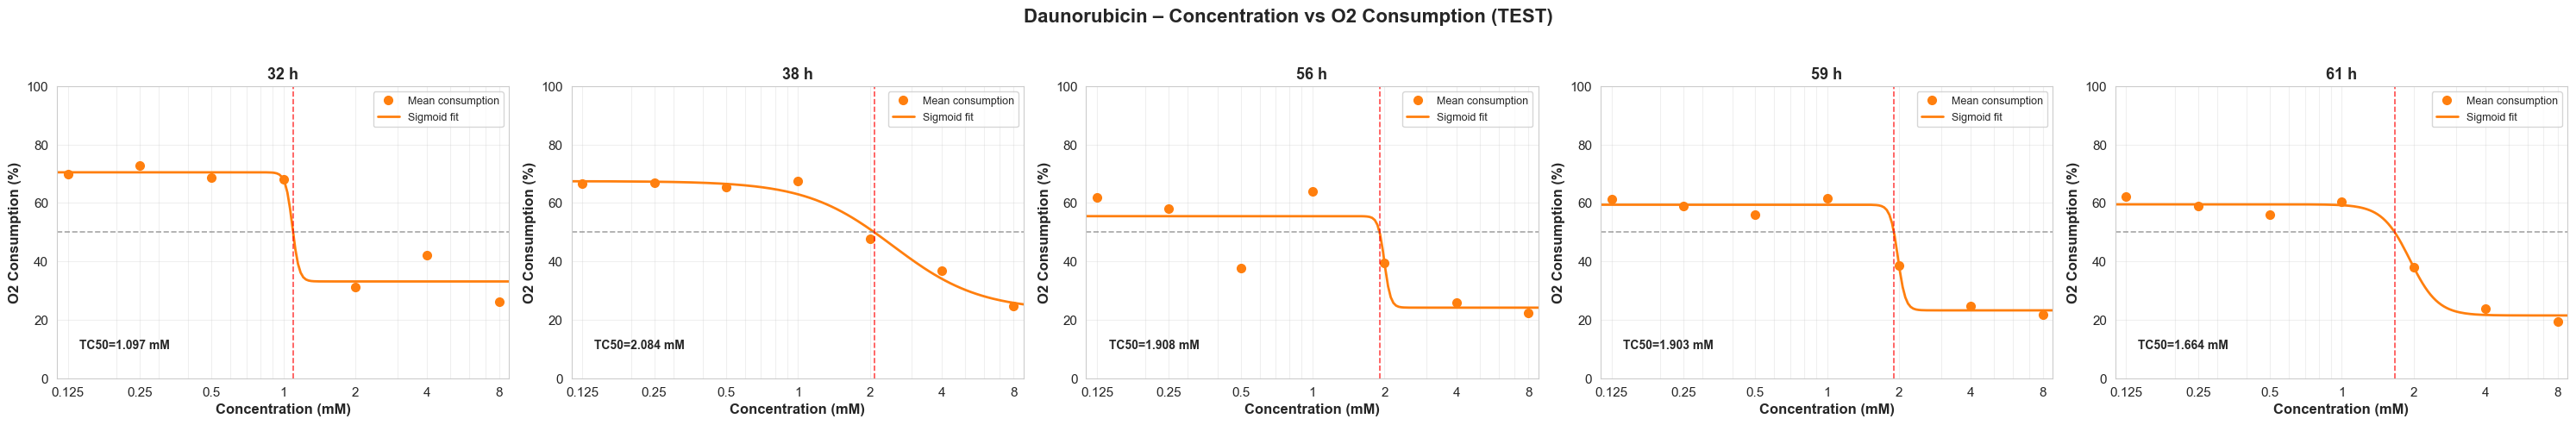


🔬 Chlorpromazine
   Time points: [22, 27, 32, 37]
   ✓ Preview displayed (not saved)


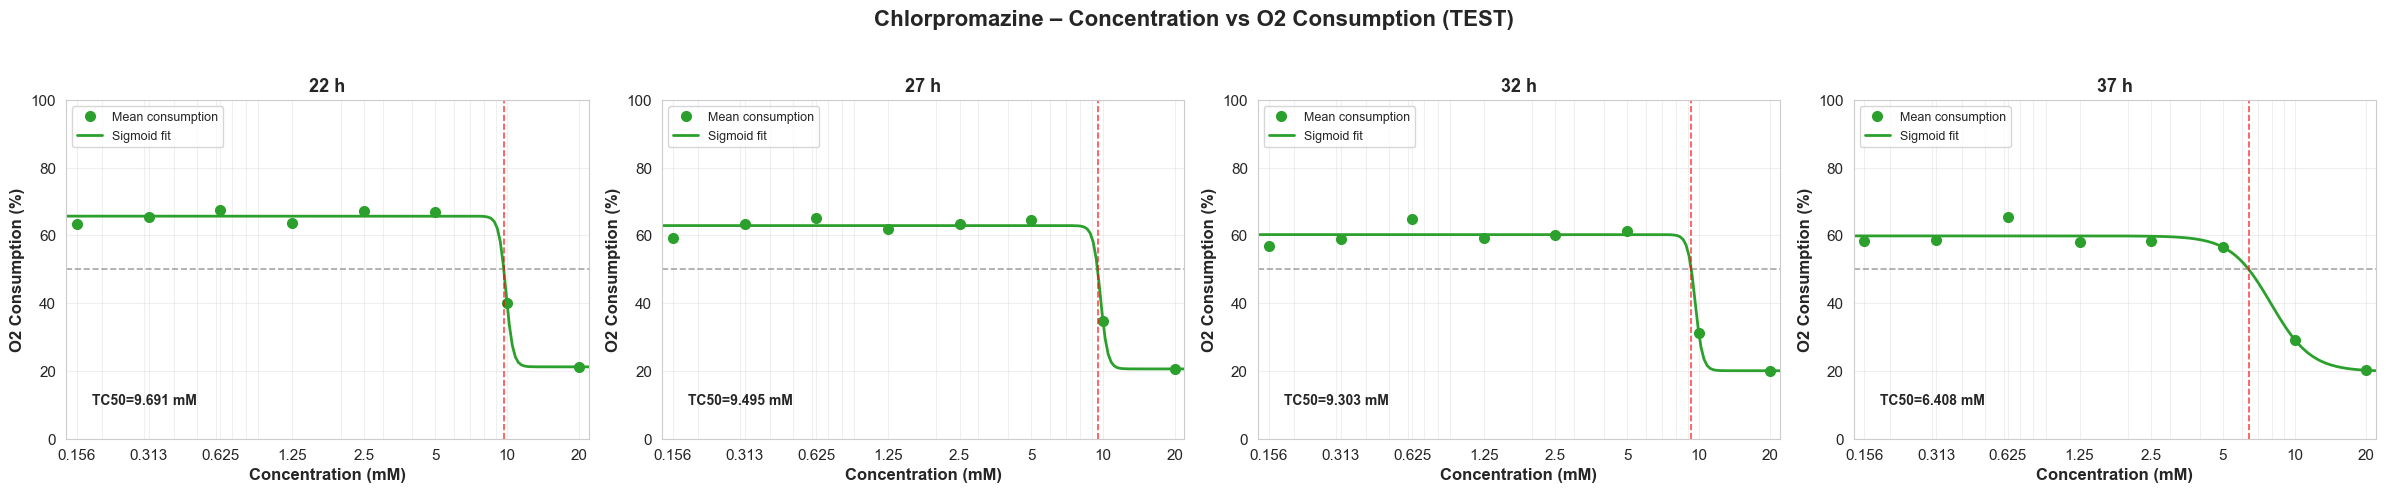


🔬 Doxorubicin
   Time points: [17, 24, 27, 72]
   ✓ Preview displayed (not saved)


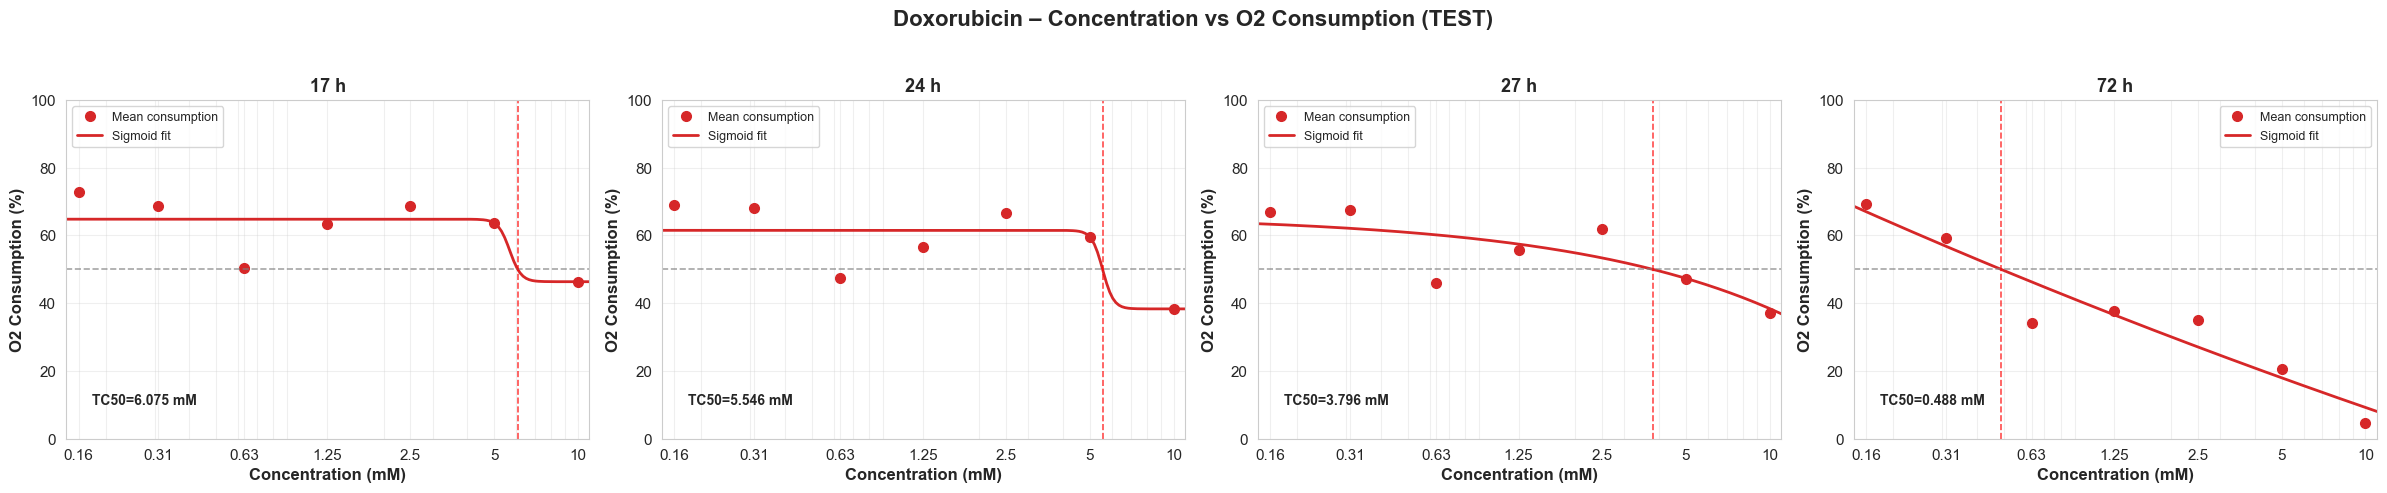


🔬 Cobimetinib
   Time points: [32, 38, 27, 29, 61, 35, 53, 56]
   ℹ Using 30.0h (closest to 29h)
   ✓ Preview displayed (not saved)


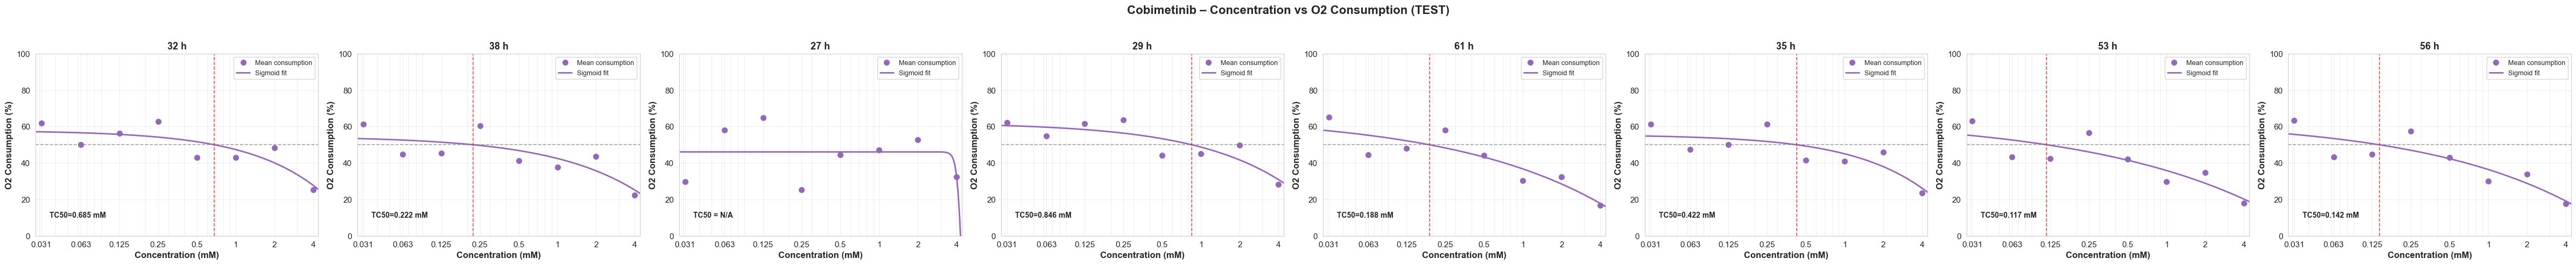


🔬 etomoxir
   Time points: [17, 24, 27, 72]
   ℹ Using 16.0h (closest to 17h)
   ℹ Using 71.0h (closest to 72h)
   ✓ Preview displayed (not saved)


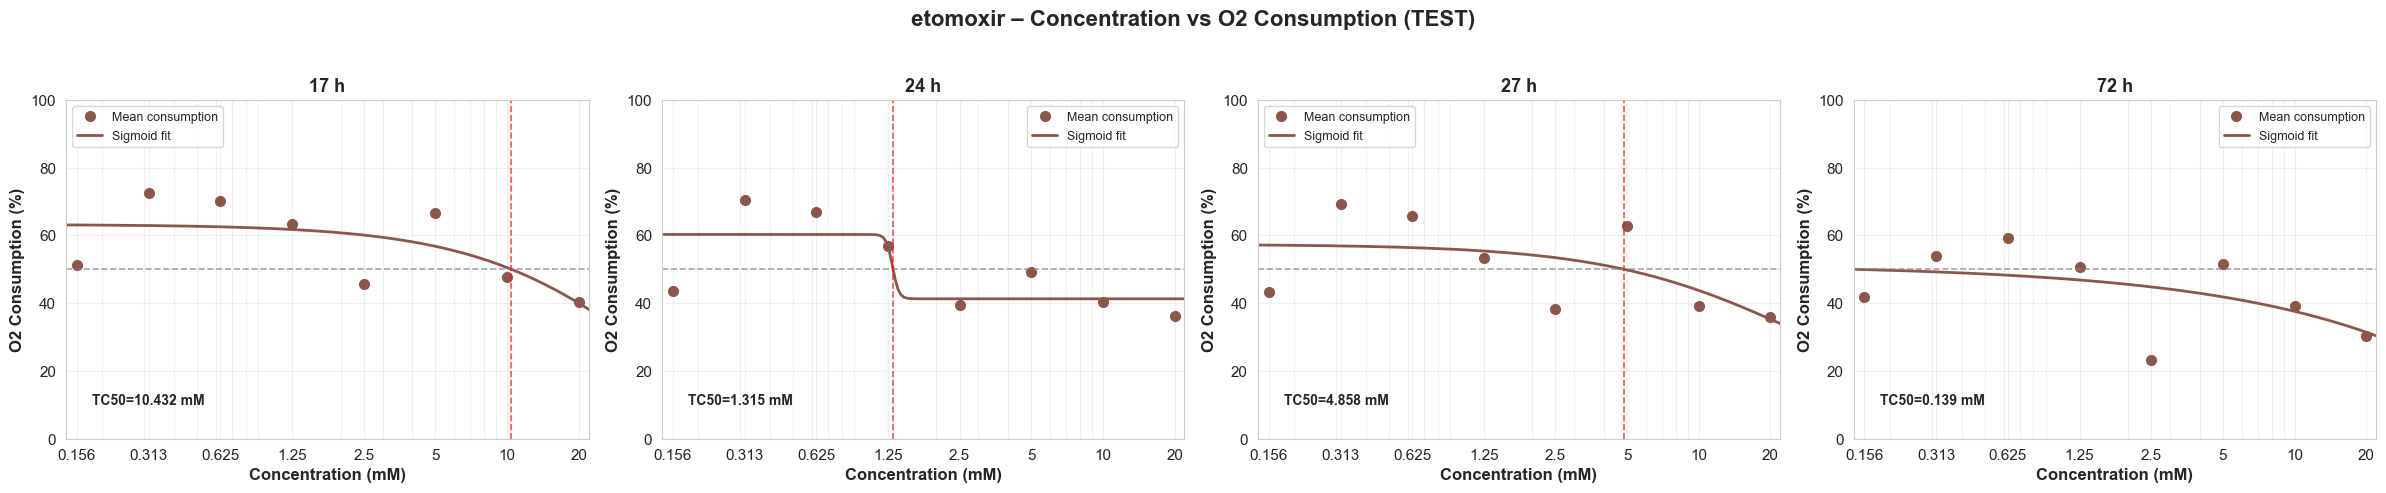


🔬 Vandetanib
   Time points: [30, 32, 40]
   ✓ Preview displayed (not saved)


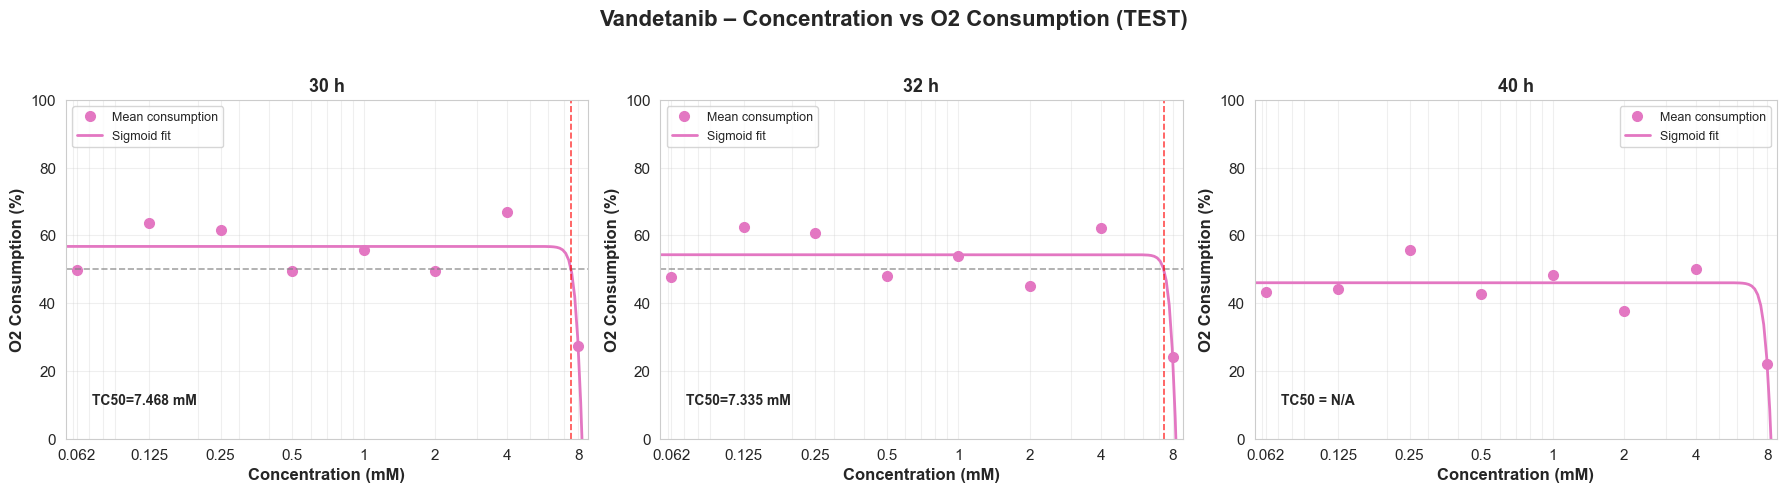


🔬 Erlotinib
   Time points: [40]
   ✓ Preview displayed (not saved)


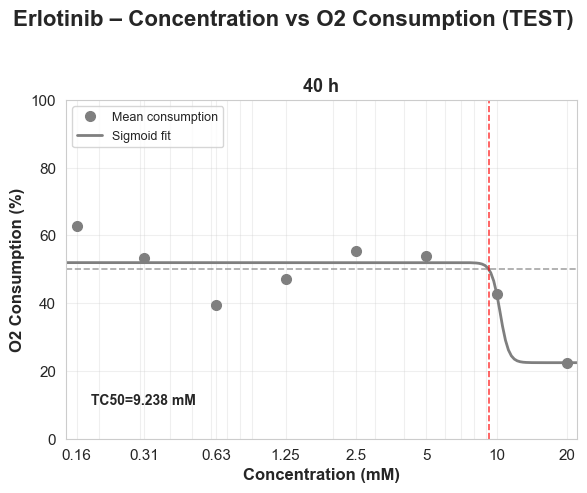


✅ Test plots complete - no files saved


In [5]:
# Cell #10
# Depends on: 1, 2, 3, 4, 5
# Purpose: Custom Drug/Time Selection - Testing (No Saving)

# ============================================================================
# CONFIGURE YOUR TEST PLOTS HERE
# ============================================================================

TEST_SELECTIONS = {
    'Epirubicin': [24, 27, 32, 38, 17],
    'Daunorubicin': [32, 38, 56, 59, 61],
    'Chlorpromazine': [22, 27, 32, 37],
    'Doxorubicin': [17, 24, 27, 72],
    'Cobimetinib': [32, 38, 27, 29, 61, 35, 53, 56],
    'etomoxir': [17, 24, 27, 72],
    'Vandetanib': [30, 32, 40],
    'Erlotinib': [40],
    # Add more drugs and timepoints as needed:
    # 'DrugName': [hour1, hour2, hour3],
}

# ============================================================================

print("🧪 Testing Custom Plot Selection (NOT saving)...")
print("=" * 80)

tc50_results, _, _ = generate_tc50_plots(
    drug_selections=TEST_SELECTIONS,
    drug_data=df_o2_raw,
    output_dir=OUTPUT_DIR,
    save_files=False,
    test_mode=True
)

print("\n" + "="*80)
print("✅ Test plots complete - no files saved")
print("=" * 80)


## Custom Plot Generation (With Excel Export)

Use this section to generate final plots for specific drugs and time points AND save the Excel data export.

**Purpose:** Once you've identified the drugs/timepoints you want, use this cell to generate plots and save Excel files like Cell #9.

📊 Generating Custom Plots and Excel Export...

🔬 Epirubicin
   Time points: [32]
   💾 Saved panel figure: Epirubicin_TC50.png


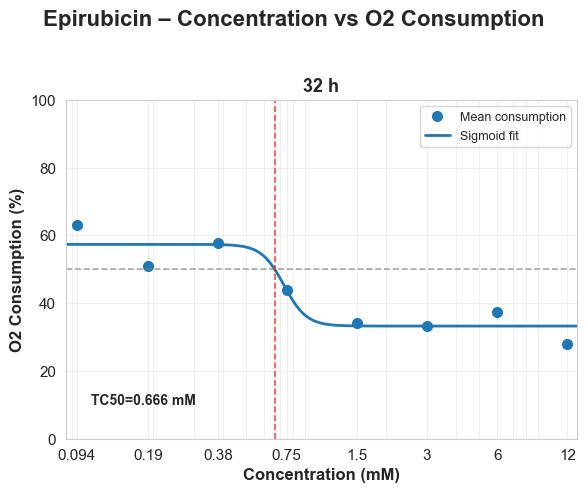


🔬 Daunorubicin
   Time points: [32]
   ⚠ Using partial match: 'Daunorubicin of' for 'Daunorubicin'
   💾 Saved panel figure: Daunorubicin_TC50.png


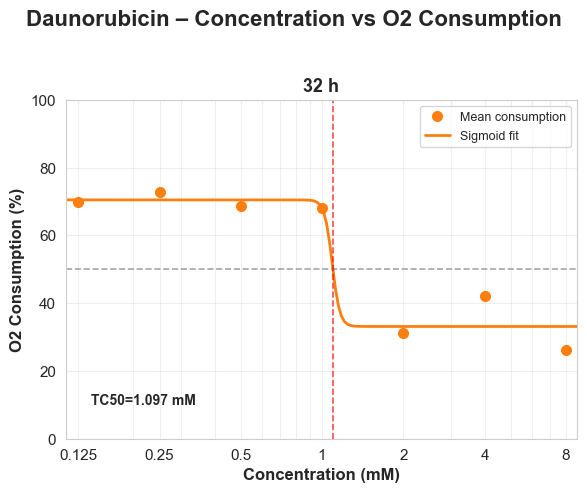


🔬 Cobimetinib
   Time points: [32, 29]
   ℹ Using 30.0h (closest to 29h)
   💾 Saved panel figure: Cobimetinib_TC50.png


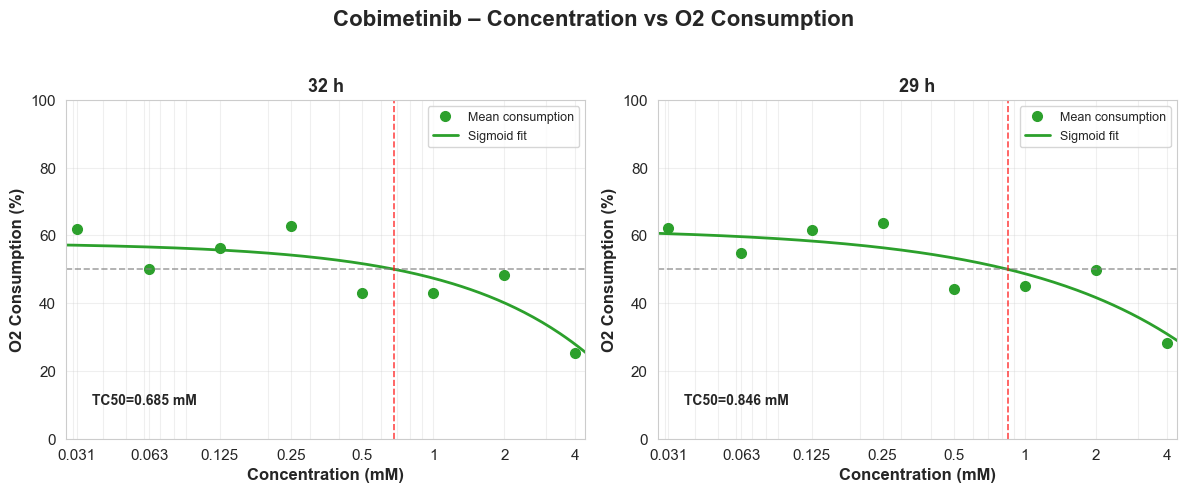


🔬 Chlorpromazine
   Time points: [32]
   💾 Saved panel figure: Chlorpromazine_TC50.png


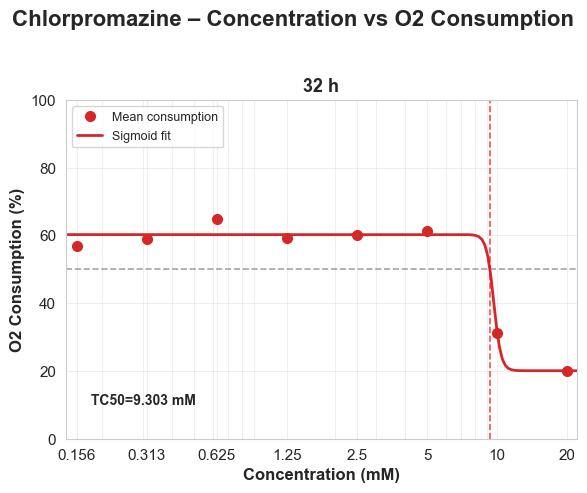


💾 Saving Data to Excel: TC50_20251224_113422.xlsx

   ✓ Summary sheet: 5 entries
   ✓ Epirubicin_32h: 8 rows
   ✓ Daunorubicin_32h: 7 rows
   ✓ Cobimetinib_32h: 8 rows
   ✓ Cobimetinib_29h: 8 rows
   ✓ Chlorpromazine_32h: 8 rows

✅ Excel file saved successfully!
   Location: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Output\TC50_Plots\TC50_20251224_113422.xlsx
   Total sheets: 6
   Timestamp: 2025-12-24 11:34:20

📊 TC50 SUMMARY:


,Drug,Time_h,TC50_mM
0,Epirubicin,32,0.665938
1,Daunorubicin,32,1.097318
2,Cobimetinib,32,0.684796
3,Cobimetinib,29,0.845903
4,Chlorpromazine,32,9.302698


WindowsPath('c:/Users/NoahB/Documents/HebrewU Bioengineering/Cardiac_RODEO/Output/TC50_Plots/TC50_20251224_113422.xlsx')

In [6]:
# Cell #11
# Depends on: 1, 2, 3, 4, 5
# Purpose: Custom Drug/Time Selection - Production (With Excel Export)

# ============================================================================
# CONFIGURE YOUR FINAL PLOTS HERE
# ============================================================================

FINAL_SELECTIONS = {
    'Epirubicin': [32],
    'Daunorubicin': [32],
    'Cobimetinib': [32, 29],
    'Chlorpromazine': [32],
    # Add more drugs and timepoints as needed:
    # 'DrugName': [hour1, hour2, hour3],
}

# ============================================================================

print("📊 Generating Custom Plots and Excel Export...")
print("=" * 80)

tc50_results, drug_export_data, timestamp = generate_tc50_plots(
    drug_selections=FINAL_SELECTIONS,
    drug_data=df_o2_raw,
    output_dir=OUTPUT_DIR,
    save_files=True,
    test_mode=False
)

# Save Excel file
save_tc50_excel(drug_export_data, tc50_results, timestamp, OUTPUT_DIR)
